# Bepaling trend met een tijdreeksmodel en een staptrend

_Ruben Caljé, Davíd Brakenhoff en Martin Vonk, Artesia, 2026_

---

Dit notebook bevat een voorbeeld van het toepassen van de KRW trendanalyse
methode met een tijdreeksmodel. Het betreft een model met een staptrend,
hierbij wordt de gemiddelde verandering in de grondwaterstand bepaald 
tussen twee periodes, waarbij de verandering in de grondwaterstand als een
stap wordt gemodelleerd.

# Setup

## Packages

In [1]:
import numpy as np
import pandas as pd
import pastas as ps

## Data inlezen

In [2]:
df = pd.read_csv("../data/GMW25B000976_1.csv", index_col=0, parse_dates=True)
head = df["GMW25B000976_1"].dropna()
prec = df["RD_ZAANDIJK_230"].dropna()
evap = df["EV24_WIJK-AAN-ZEE_257"].dropna()

periods = [
    (pd.Timestamp("2000-01-01 00:00:00"), pd.Timestamp("2005-12-31 23:59:59")),
    (pd.Timestamp("2018-01-01 00:00:00"), pd.Timestamp("2023-12-31 23:59:59")),
]

## Data bewerking

Maak van de grondwaterstand een reeks met twee periodes, waarbij de eerste periode loopt van 2000 tot en met 2005 en de tweede periode van 2018 tot en met 2023. De verandering in de grondwaterstand tussen deze twee periodes wordt als een stap gemodelleerd.

In [3]:
head_sel = pd.Series(np.nan, index=head.index, name=head.name)
for period in periods:
    head_sel.loc[period[0] : period[1]] = head.loc[period[0] : period[1]]
head_sel = head_sel.dropna()

# Tijdreeksmodel

Maak een tijdreeksmodel aan met de grondwaterstand en neerslag en verdamping als verklarende variabele.  Het betreft hier alleen deeltoets B, waarbij de trend wordt bepaald aan de hand van een stap. Dit verondersteld dat de antropogene invloeden op de grondwaterstand tussen de twee periodes als een stap kan worden gemodelleerd en dat de contributie van neerslag en verdamping klopt.

In [4]:
ml = ps.Model(head_sel)
rm = ps.RechargeModel(prec=prec, evap=evap, rfunc=ps.Gamma(), name="rech")
sm = ps.StepModel(tstart=pd.Timestamp("2006-01-01"), name="step")
ml.add_stressmodel([rm, sm])
# aantal settings voor het model
ml.set_parameter("rech_a", pmax=5_000.0)
ml.set_parameter("rech_f", pmax=-0.5, pmin=-1.5)
solver_kwargs = {"x_scale": "jac", "jac": "3-point"}
ml.solve(report=False, **solver_kwargs)
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(report=True, initial=False, **solver_kwargs)

Fit report GMW25B000976_1           Fit Statistics
nfev     11                     EVP          85.32
nobs     286                    R2            0.85
noise    True                   RMSE          0.03
tmin     2000-01-14 12:00:00    AICc      -2144.03
tmax     2023-12-28 12:00:00    BIC       -2118.84
freq     D                      Obj           0.08
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.        Yes
solver   LeastSquares           weights         No

Parameters (7 optimized)
                   optimal        initial   vary
rech_A            0.046261       0.049393   True
rech_n            0.869966       0.865809   True
rech_a           91.217767      93.924574   True
rech_f           -0.876082      -0.808666   True
step_d            0.080860       0.080805   True
step_tstart  732312.000000  732312.000000  False
constant_d       -1.464928      -1.474154   True
noise_alpha      17.822939      14.000000   True


# Resultaat

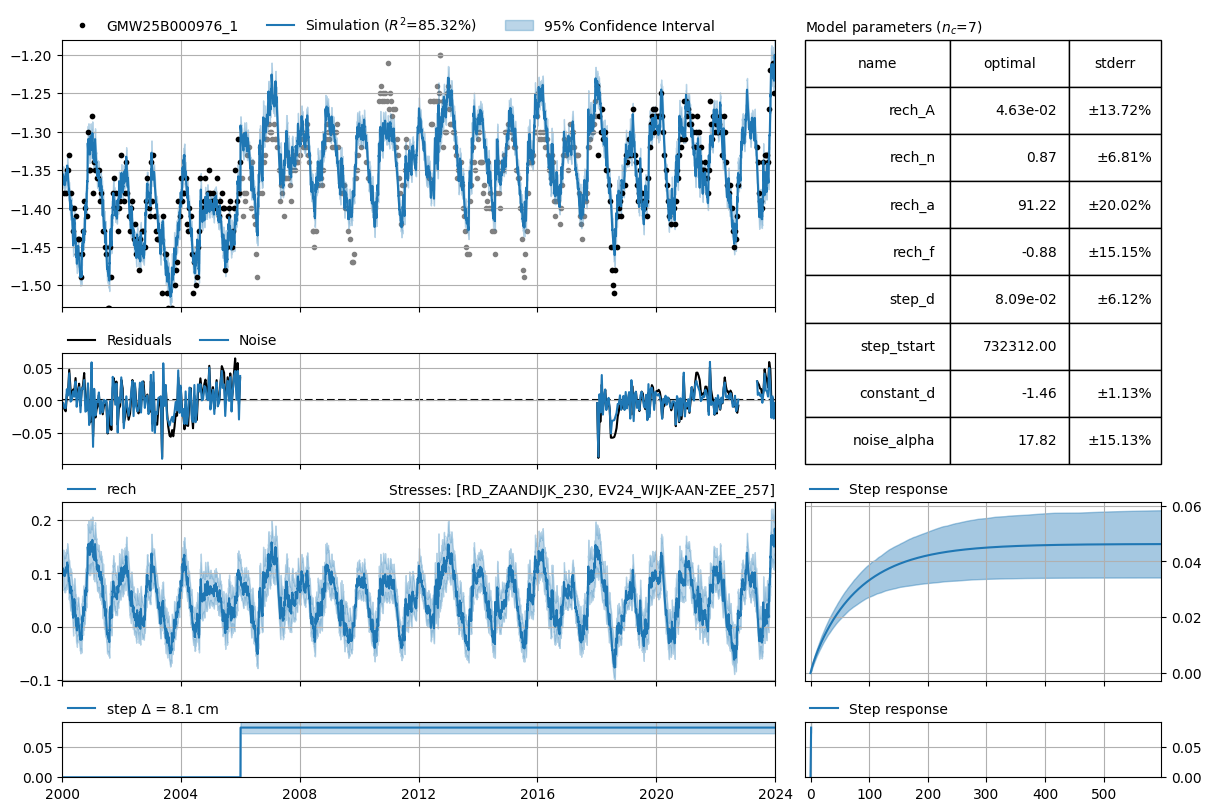

In [5]:
axd = ml.plots.results_mosaic(figsize=(12, 8), stderr=True)
axd["sim"].plot(
    head.index,
    head.values,
    marker=".",
    color="gray",
    linestyle="None",
    zorder=0,
)
sim_ci = ml.solver.ci_simulation()
axd["sim"].set_ylim(
    sim_ci.iloc[:, 0].min(),
    sim_ci.iloc[:, 1].max(),
)
axd["sim"].set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2024-01-01"))
axd["sim"].fill_between(
    sim_ci.index,
    sim_ci.iloc[:, 0],
    sim_ci.iloc[:, 1],
    color="C0",
    alpha=0.3,
    label="95% Confidence Interval",
)
axd["sim"].legend(loc=(0, 1), frameon=False, ncol=3)

rech_ci = ml.solver.ci_contribution("rech")
axd["con_rech"].set_ylim(
    rech_ci.iloc[:, 0].min(),
    rech_ci.iloc[:, 1].max(),
)
axd["con_rech"].fill_between(
    rech_ci.index, rech_ci.iloc[:, 0], rech_ci.iloc[:, 1], color="C0", alpha=0.3
)
step_ci = ml.solver.ci_contribution("step")
axd["con_step"].set_ylim(
    step_ci.iloc[:, 0].min(),
    step_ci.iloc[:, 1].max(),
)
axd["con_step"].fill_between(
    step_ci.index, step_ci.iloc[:, 0], step_ci.iloc[:, 1], color="C0", alpha=0.3
)
handles, labels = axd["con_step"].get_legend_handles_labels()
labels[0] = f"step Δ = {ml.parameters.at['step_d', 'optimal'] * 100:0.1f} cm"
axd["con_step"].legend(handles, labels, loc=(0, 1), frameon=False, ncol=1)

rech_step_ci = ml.solver.ci_step_response("rech")
axd["rf_rech"].fill_between(
    rech_step_ci.index,
    rech_step_ci.iloc[:, 0],
    rech_step_ci.iloc[:, 1],
    color="C0",
    alpha=0.4,
    # label = "95% Confidence Interval",
)
axd["rf_rech"].legend(loc=(0, 1), frameon=False, ncol=1)
step_step_ci = ml.solver.ci_step_response("step")
axd["rf_step"].fill_between(
    [0.0, 1.0],
    [step_step_ci.iat[0, 0], step_step_ci.iat[0, 0]],
    [step_step_ci.iat[0, 1], step_step_ci.iat[0, 1]],
    color="C0",
    alpha=0.4,
    # label = "95% Confidence Interval",
)
axd["rf_step"].legend(loc=(0, 1), frameon=False, ncol=1)
axd["rf_step"].set_xlim(-10, None)
axd["rf_step"].set_ylim(
    min(0.0, step_step_ci.iloc[:, 0].min()), max(0.0, step_step_ci.iloc[:, 1].max())
);

Voor dit model is de gemiddelde verandering in de grondwaterstand 8.1 cm zoals te zien aan de waarde van de staptrend.